<a href="https://colab.research.google.com/github/JCF-the-creator/GoogleColabGeneration/blob/main/Aula_R_Estatistica_Previsao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
library(ggplot2)
install.packages("forecast")
library(forecast)

dados <- read.csv("dados.csv") #aqui importa os dados para serem utilizados


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’




     Qtr1 Qtr2 Qtr3 Qtr4
1945   NA   87   82   75
1946   63   50   43   32
1947   35   60   54   55
1948   36   39   NA   NA
1949   69   57   57   51
1950   45   37   46   39
1951   36   24   32   23
1952   25   32   NA   32
1953   59   74   75   60
1954   71   61   71   57
1955   71   68   79   73
1956   76   71   67   75
1957   79   62   63   57
1958   60   49   48   52
1959   57   62   61   66
1960   71   62   61   57
1961   72   83   71   78
1962   79   71   62   74
1963   76   64   62   57
1964   80   73   69   69
1965   71   64   69   62
1966   63   46   56   44
1967   44   52   38   46
1968   36   49   35   44
1969   59   65   65   56
1970   66   53   61   52
1971   51   48   54   49
1972   49   61   NA   NA
1973   68   44   40   27
1974   28   25   24   24


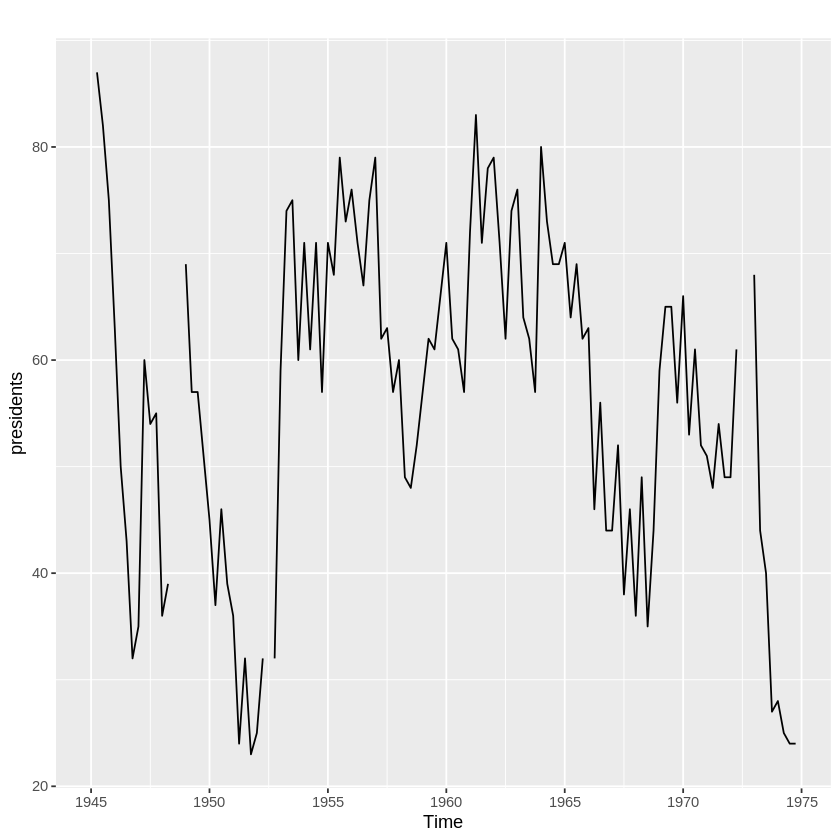

In [4]:
library(ggplot2)
# teste de Hipotese
# H_0 : os dados estão normalmente distribuídos
# H_1 : os dados não têm distribuição normal
# usaremos o teste de shipiro
# alpha = 0,05

help(presidents) # informações sobre o pacote de dados
print(presidents)
autoplot(presidents)#gera um grafico


	Shapiro-Wilk normality test

data:  presidents
W = 0.96757, p-value = 0.007226


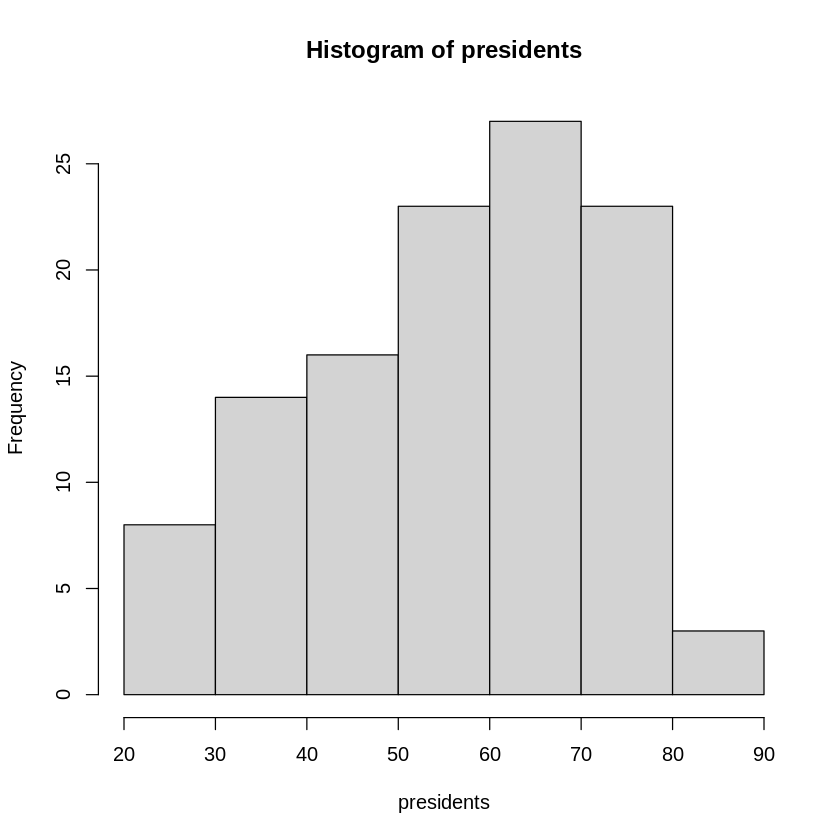

In [7]:
shapiro.test(presidents)
hist(presidents)

In [1]:
# vamos construir o modelo (ARIMA)
# mas vamos olhar para os resíduos
modelo = auto.arima(presidents)
checkresiduals(modelo)
#autoplot(modelo$residuals)
# H_0 : os dados são normalmente distribuidos
#shapiro.test(modelo$residuals)
#hist(modelo$residuals)
#acf(modelo$residuals, na.action = na.pass) # funcao de autocorrelação

ERROR: Error in auto.arima(presidents): could not find function "auto.arima"


In [2]:
# hold out do modelo (treino e teste)
# ou seja, vamos dividir a base em dois conjuntos (treino e teste)

# 1. Separar a base em Treino (1945 a 1971) e Teste (1972 a 1974)
dados_treino <- window(presidents, end=c(1971, 4))
dados_teste  <- window(presidents, start=c(1972, 1))

# 2. Ajustar o auto.arima apenas nos dados de treino
modelo_treino <- auto.arima(dados_treino)

# 3. Prever os próximos 12 trimestres (3 anos)
predicao_futura <- forecast(modelo_treino, h=12)

# 4. Confrontar graficamente a previsão (e intervalos de confiança) com os dados reais de teste
plot(predicao_futura, main="Confrontando Previsão com Dados Reais de Teste")
lines(dados_teste, col="red", lwd=2) # Adiciona a linha real de teste em vermelho
legend("bottomleft", legend=c("Previsão ARIMA", "Dados Reais Omitidos"), col=c("blue", "red"), lty=1, lwd=2)

# 5. Calcular a acurácia exata comparando o previsto com o teste real
accuracy(predicao_futura, dados_teste)


ERROR: Error in auto.arima(dados_treino): could not find function "auto.arima"
